# Football Player and Ball Detection & Tracking using YOLOv8

This project uses YOLOv8 for detecting football players and the ball
in video footage and ByteTrack for maintaining object identities
across frames.

## Technologies
- Python
- PyTorch
- Ultralytics YOLOv8
- OpenCV
- Roboflow
- ByteTrack
- Google Colab

## Workflow
1. Download the football detection dataset from Roboflow
2. Load a pretrained YOLOv8 model
3. Fine-tune the model on the dataset
4. Evaluate the trained model
5. Track detected objects using ByteTrack
6. Visualize the ball trajectory
7. Generate the processed output video

In [1]:
# Install required libraries
!pip install -q ultralytics roboflow opencv-python matplotlib numpy tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import drive
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
# Verify GPU availability
import torch
device = '0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if device=='0' else 'CPU'})")

Using device: 0 (Tesla T4)


In [4]:
#initialize roboflow and download the dataset
import getpass
api_key = getpass.getpass("Enter your Roboflow API key: ")
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
dataset = project.version(1).download("yolov8")

Enter your Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-1 in yolov8:: 100%|██████████| 1338/1338 [00:00<00:00, 3454.38it/s]


In [5]:
# Verify Dataset Structure
import yaml
with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_info = yaml.safe_load(f)

print(f"Classes: {data_info['names']}")
print(f"Dataset location: {dataset.location}")

Classes: ['ball', 'goalkeeper', 'player', 'referee']
Dataset location: /content/football-players-detection-1


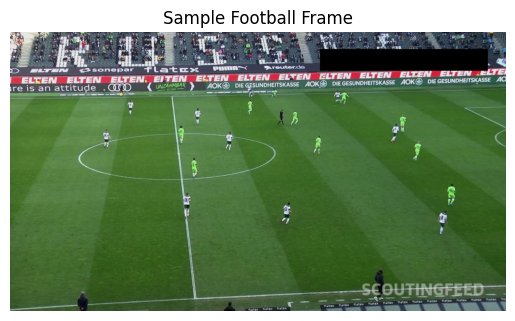

In [6]:
# Visualize a Sample
sample_img = os.path.join(dataset.location, "train/images", os.listdir(dataset.location + "/train/images")[7])
img = cv2.imread(sample_img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Sample Football Frame")
plt.axis('off')
plt.show()

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_yolo_model, nbs=64, nms=None, op

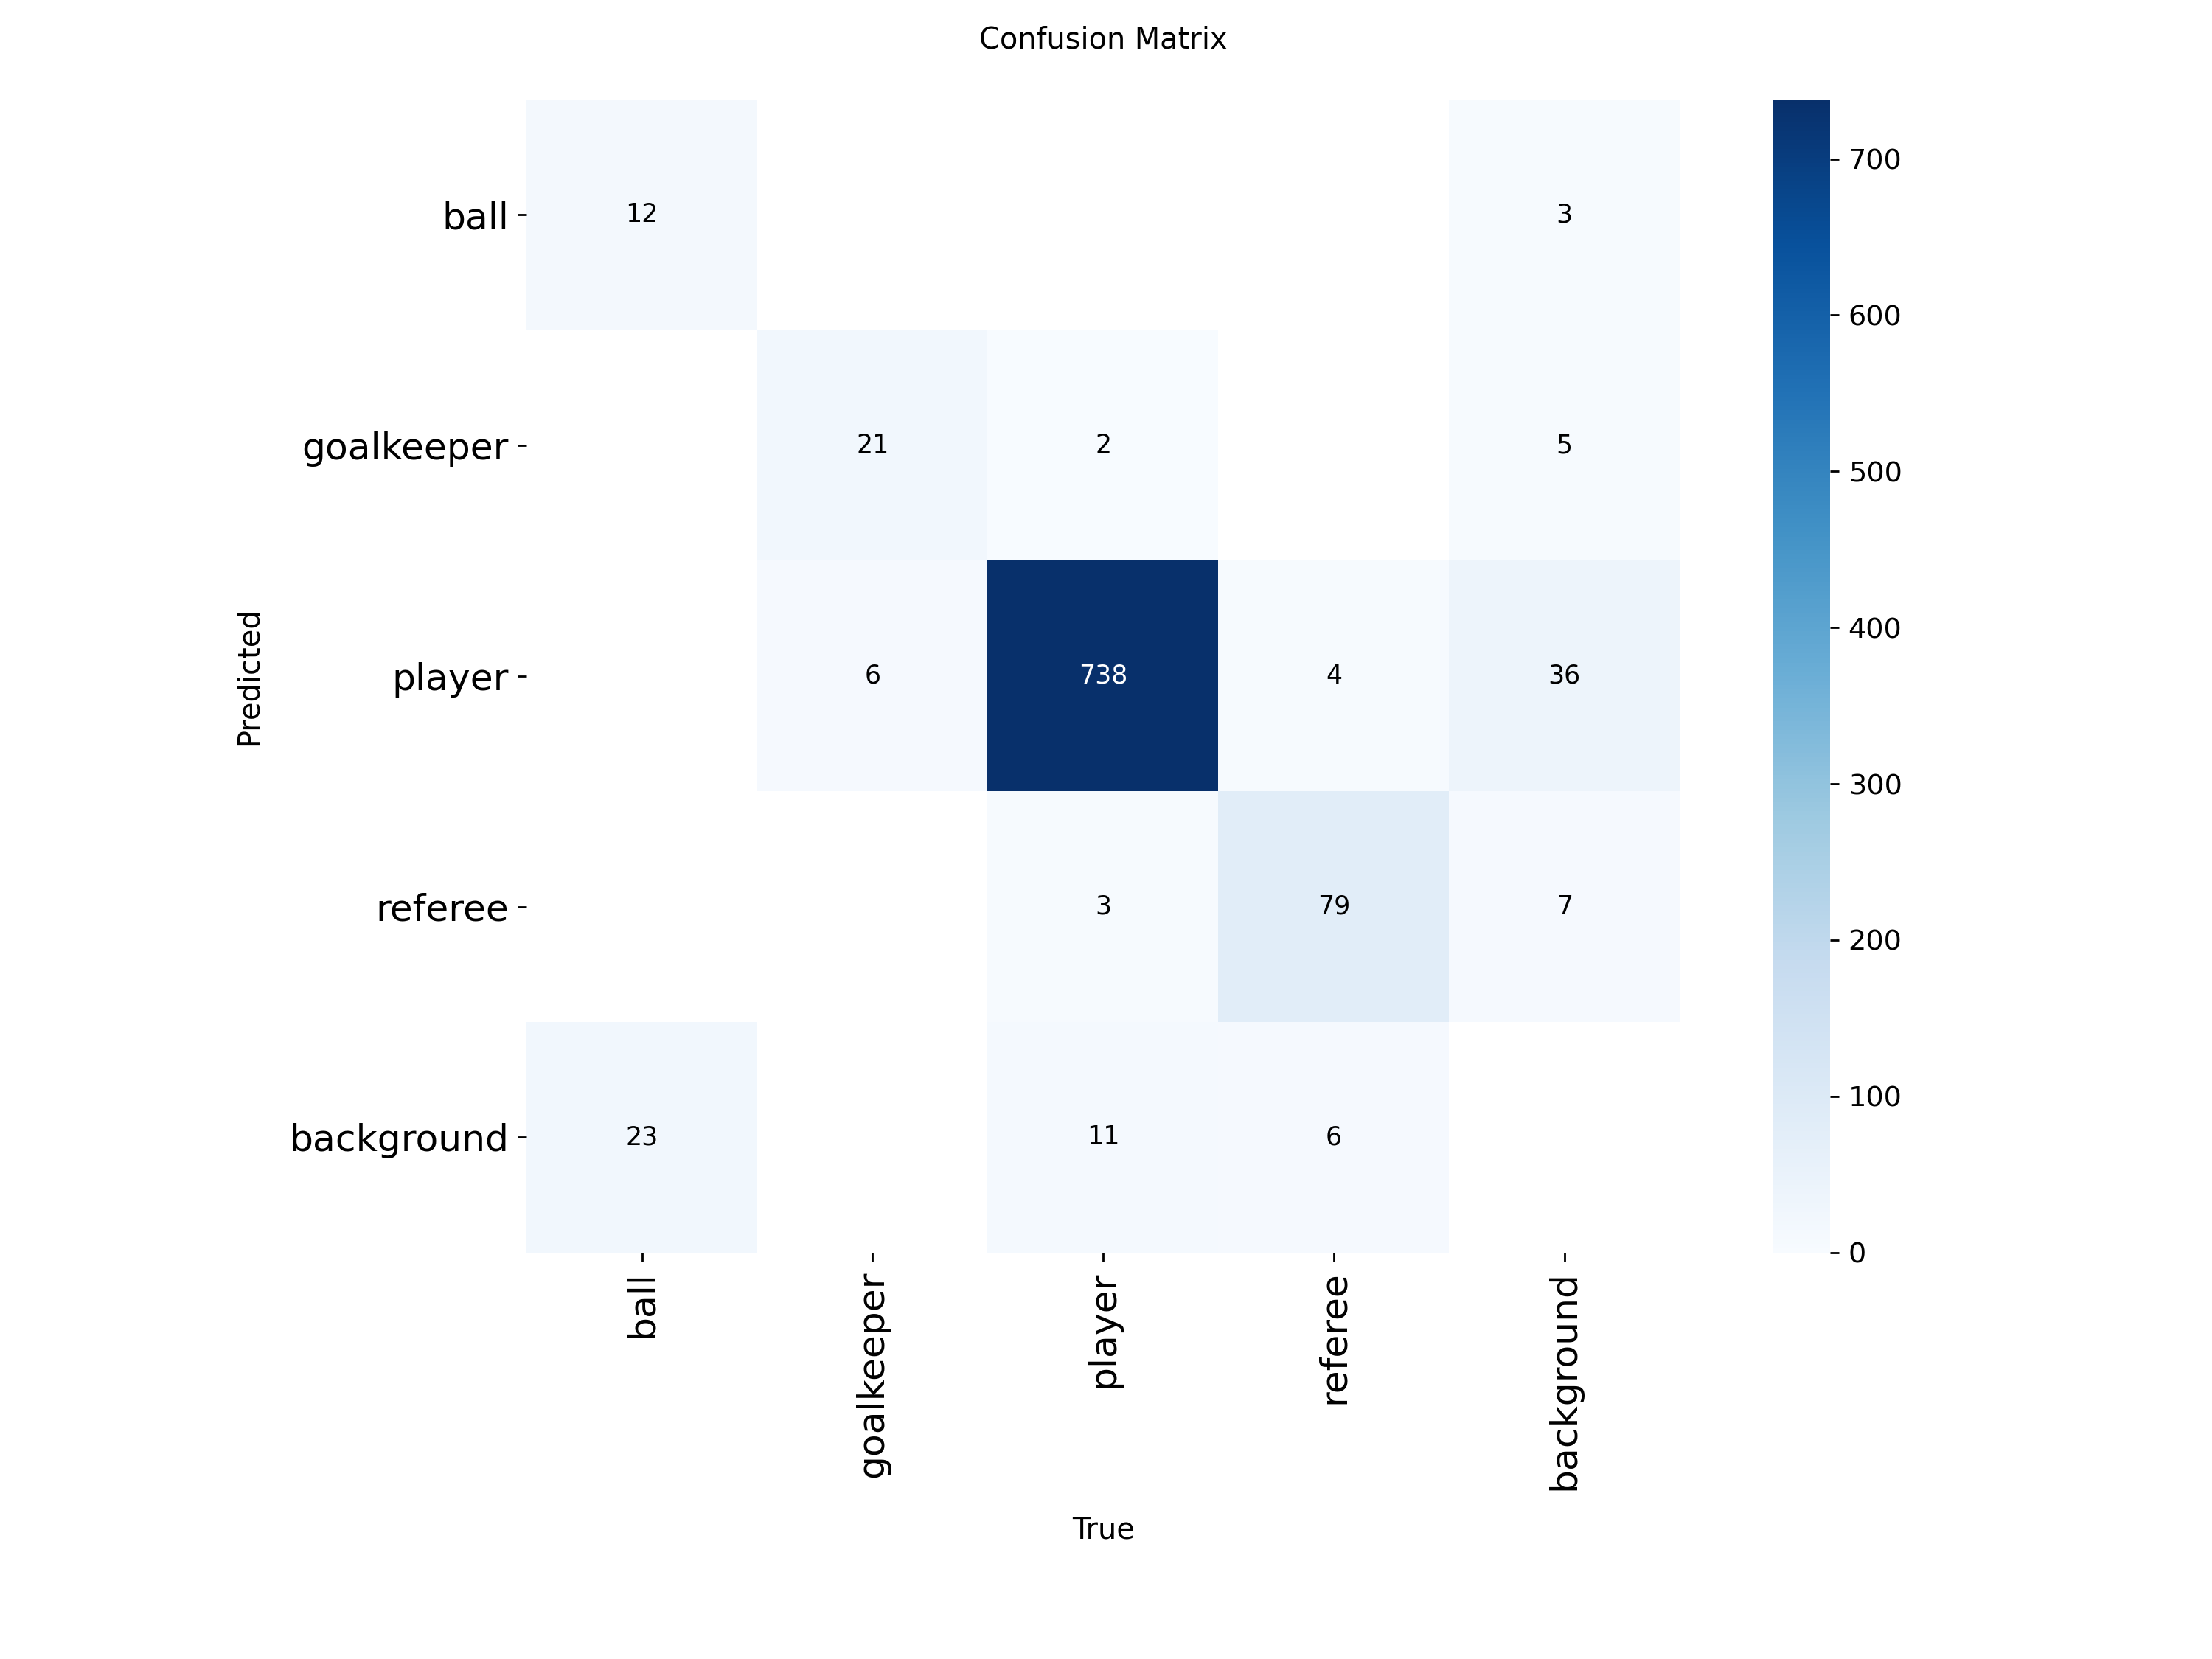

In [7]:
# Load YOLOv8s pretrained model
model_variant = "yolov8s.pt" # Options: yolov8n.pt, yolov8s.pt, yolov8m.pt
model = YOLO(model_variant)

# Train the model
# Using 50 epochs as requested; adjust imgsz to 640 for football clarity
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    name="football_yolo_model"
)

# Evaluation metrics are automatically saved by Ultralytics
# View the confusion matrix
from IPython.display import Image
Image(filename=f"runs/detect/football_yolo_model/confusion_matrix.png", width=600)

In [8]:
def process_football_video(input_video_path, output_video_path, model_path):
    model = YOLO(model_path)
    cap = cv2.VideoCapture(input_video_path)

    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # Store history for the tracking path
    track_history = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Run tracking (persist=True keeps IDs across frames)
        results = model.track(frame, persist=True, tracker="bytetrack.yaml", conf=0.3)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu().numpy()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            classes = results[0].boxes.cls.int().cpu().tolist()

            for box, track_id, cls in zip(boxes, track_ids, classes):
                # Target the ball class (check your data.yaml, typically ball is class 0)
                if model.names[cls] == 'ball':
                    x, y, w, h = box
                    track_history.append((float(x), float(y)))

                    # Draw Bounding Box
                    cv2.rectangle(frame, (int(x-w/2), int(y-h/2)), (int(x+w/2), int(y+h/2)), (0, 255, 0), 2)
                    cv2.putText(frame, f"Ball ID: {track_id}", (int(x), int(y-10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Draw Tracking Path (Tail)
        for i in range(1, len(track_history)):
            cv2.line(frame, (int(track_history[i-1][0]), int(track_history[i-1][1])),
                     (int(track_history[i][0]), int(track_history[i][1])), (0, 255, 255), 2)

        out.write(frame)

    cap.release()
    out.release()
    print(f"Processed video saved to {output_video_path}")

In [10]:
from google.colab import files

# Step 1: Upload
uploaded = files.upload()
video_name = list(uploaded.keys())[0]

# Step 2: Run Inference
best_model_path = "runs/detect/football_yolo_model/weights/best.pt"
process_football_video(video_name, "football_tracking_output.mp4", best_model_path)

# Step 3: Download Output
files.download("football_tracking_output.mp4")

Streaming output truncated to the last 5000 lines.
Speed: 1.0ms preprocess, 9.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 goalkeeper, 14 players, 1 referee, 10.9ms
Speed: 0.7ms preprocess, 10.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 players, 1 referee, 8.8ms
Speed: 1.9ms preprocess, 8.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 goalkeeper, 13 players, 1 referee, 9.9ms
Speed: 0.6ms preprocess, 9.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 goalkeeper, 14 players, 1 referee, 9.5ms
Speed: 0.8ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 goalkeeper, 14 players, 9.4ms
Speed: 0.7ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 goalkeeper, 13 players, 9.3ms
Speed: 0.8ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>